In [1]:
skip_cnn_training = False

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import snntorch.spikeplot as splt

# Import our models and attacks
import sys
sys.path.append('..')
from models.hybrid_snn import HybridCSNN
from models.standard_cnn import StandardCNN
from attacks.adversarial import snn_fgsm_attack, fgsm_attack

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Using device: {device}")

Using device: cpu


In [3]:
# MNIST Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0,), (1,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [4]:
def train_model(model, loader, optimizer, is_snn=False):
    model.train()
    total_loss = 0
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        
        if is_snn:
            # Sum spikes/logits over T steps
            loss = nn.CrossEntropyLoss()(output.sum(dim=0), target)
        else:
            loss = nn.CrossEntropyLoss()(output, target)
            
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


In [5]:
cnn_model = StandardCNN().to(device)
cnn_opt = optim.Adam(cnn_model.parameters(), lr=1e-3)


def cnn_training(skip_cnn_training):
    if skip_cnn_training:
        print("Skipping CNN training...")
    else:
        print("Training CNN...")
        for epoch in range(3):
            loss = train_model(cnn_model, train_loader, cnn_opt)
            print(f"CNN Epoch {epoch+1}, Loss: {loss:.4f}")

cnn_training(skip_cnn_training)

Training CNN...
CNN Epoch 1, Loss: 0.2147
CNN Epoch 2, Loss: 0.0567
CNN Epoch 3, Loss: 0.0408


In [6]:
snn_model = HybridCSNN(num_steps=25).to(device)

snn_opt = optim.Adam(snn_model.parameters(), lr=1e-3)

print("\nTraining Hybrid SNN...")
for epoch in range(3):
    loss = train_model(snn_model, train_loader, snn_opt, is_snn=True)
    print(f"SNN Epoch {epoch+1}, Loss: {loss:.4f}")


Training Hybrid SNN...
Step 0, Max Mem: 0.6534
Step 1, Max Mem: 1.2415
Step 2, Max Mem: 1.4261
Step 3, Max Mem: 1.3471
Step 4, Max Mem: 1.4521
Step 5, Max Mem: 1.4326
Step 6, Max Mem: 1.4604
Step 7, Max Mem: 1.5019
Step 8, Max Mem: 1.4615
Step 9, Max Mem: 1.5463
Step 10, Max Mem: 1.4601
Step 11, Max Mem: 1.5287
Step 12, Max Mem: 1.4666
Step 13, Max Mem: 1.5383
Step 14, Max Mem: 1.4679
Step 15, Max Mem: 1.5020
Step 16, Max Mem: 1.4648
Step 17, Max Mem: 1.5189
Step 18, Max Mem: 1.5210
Step 19, Max Mem: 1.5325
Step 20, Max Mem: 1.5226
Step 21, Max Mem: 1.4654
Step 22, Max Mem: 1.5481
Step 23, Max Mem: 1.4728
Step 24, Max Mem: 1.5026
Step 0, Max Mem: 0.6007
Step 1, Max Mem: 1.1413
Step 2, Max Mem: 1.4177
Step 3, Max Mem: 1.2688
Step 4, Max Mem: 1.4435
Step 5, Max Mem: 1.3638
Step 6, Max Mem: 1.3148
Step 7, Max Mem: 1.4016
Step 8, Max Mem: 1.3478
Step 9, Max Mem: 1.4098
Step 10, Max Mem: 1.3735
Step 11, Max Mem: 1.4248
Step 12, Max Mem: 1.3963
Step 13, Max Mem: 1.4166
Step 14, Max Mem: 1.4

In [7]:
def evaluate_attack(model, loader, epsilon, is_snn=False):
    model.eval()
    correct = 0
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        
        if epsilon > 0:
            if is_snn:
                data = snn_fgsm_attack(model, device, data, target, epsilon)
            else:
                data.requires_grad = True
                output = model(data)
                loss = nn.CrossEntropyLoss()(output, target)
                model.zero_grad()
                loss.backward()
                data = fgsm_attack(data, epsilon, data.grad.data)
        
        output = model(data)
        if is_snn:
            pred = output.sum(dim=0).argmax(dim=1, keepdim=True)
        else:
            pred = output.argmax(dim=1, keepdim=True)
            
        correct += pred.eq(target.view_as(pred)).sum().item()
        
    return correct / len(loader.dataset)


In [8]:

epsilons = [0.0, 0.1, 0.2, 0.3]
cnn_accs = []
snn_accs = []

for eps in epsilons:
    print(f"Evaluating Epsilon: {eps}")
    if not skip_cnn_training:
        cnn_accs.append(evaluate_attack(cnn_model, test_loader, eps, is_snn=False))
    snn_accs.append(evaluate_attack(snn_model, test_loader, eps, is_snn=True))

Evaluating Epsilon: 0.0
Step 0, Max Mem: 0.7849
Step 1, Max Mem: 1.4913
Step 2, Max Mem: 1.4262
Step 3, Max Mem: 1.6101
Step 4, Max Mem: 1.5041
Step 5, Max Mem: 1.5726
Step 6, Max Mem: 1.6481
Step 7, Max Mem: 1.5592
Step 8, Max Mem: 1.6000
Step 9, Max Mem: 1.6309
Step 10, Max Mem: 1.5797
Step 11, Max Mem: 1.5551
Step 12, Max Mem: 1.5660
Step 13, Max Mem: 1.6121
Step 14, Max Mem: 1.6356
Step 15, Max Mem: 1.5931
Step 16, Max Mem: 1.6221
Step 17, Max Mem: 1.6530
Step 18, Max Mem: 1.6193
Step 19, Max Mem: 1.5628
Step 20, Max Mem: 1.6239
Step 21, Max Mem: 1.6237
Step 22, Max Mem: 1.5811
Step 23, Max Mem: 1.6382
Step 24, Max Mem: 1.5603
Step 0, Max Mem: 0.8288
Step 1, Max Mem: 1.5747
Step 2, Max Mem: 1.4263
Step 3, Max Mem: 1.6227
Step 4, Max Mem: 1.6840
Step 5, Max Mem: 1.5795
Step 6, Max Mem: 1.6238
Step 7, Max Mem: 1.6336
Step 8, Max Mem: 1.6112
Step 9, Max Mem: 1.5497
Step 10, Max Mem: 1.6651
Step 11, Max Mem: 1.6414
Step 12, Max Mem: 1.5770
Step 13, Max Mem: 1.6880
Step 14, Max Mem: 1.6

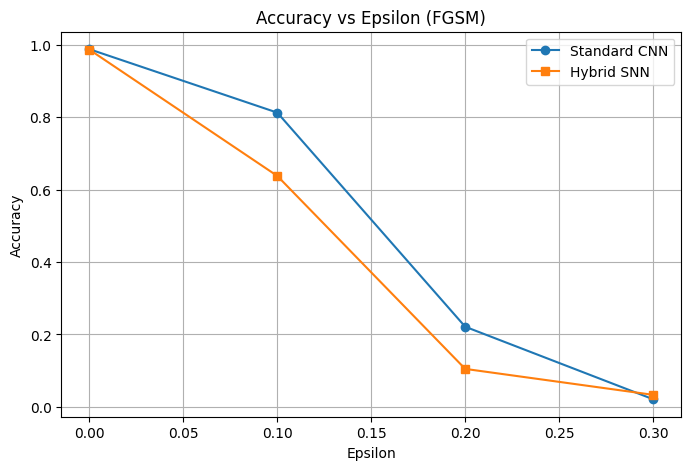

In [9]:
plt.figure(figsize=(8, 5))
if not skip_cnn_training:
    plt.plot(epsilons, cnn_accs, "o-", label="Standard CNN")
plt.plot(epsilons, snn_accs, "s-", label="Hybrid SNN")
plt.title("Accuracy vs Epsilon (FGSM)")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Step 0, Max Mem: 0.5639
Step 1, Max Mem: 1.0714
Step 2, Max Mem: 1.4223
Step 3, Max Mem: 1.2491
Step 4, Max Mem: 1.4307
Step 5, Max Mem: 1.3206
Step 6, Max Mem: 1.4176
Step 7, Max Mem: 1.3286
Step 8, Max Mem: 1.4566
Step 9, Max Mem: 1.4209
Step 10, Max Mem: 1.3590
Step 11, Max Mem: 1.4273
Step 12, Max Mem: 1.3279
Step 13, Max Mem: 1.3750
Step 14, Max Mem: 1.3211
Step 15, Max Mem: 1.4270
Step 16, Max Mem: 1.4202
Step 17, Max Mem: 1.3358
Step 18, Max Mem: 1.2475
Step 19, Max Mem: 1.4237
Step 20, Max Mem: 1.3794
Step 21, Max Mem: 1.3986
Step 22, Max Mem: 1.3746
Step 23, Max Mem: 1.4198
Step 24, Max Mem: 1.3421


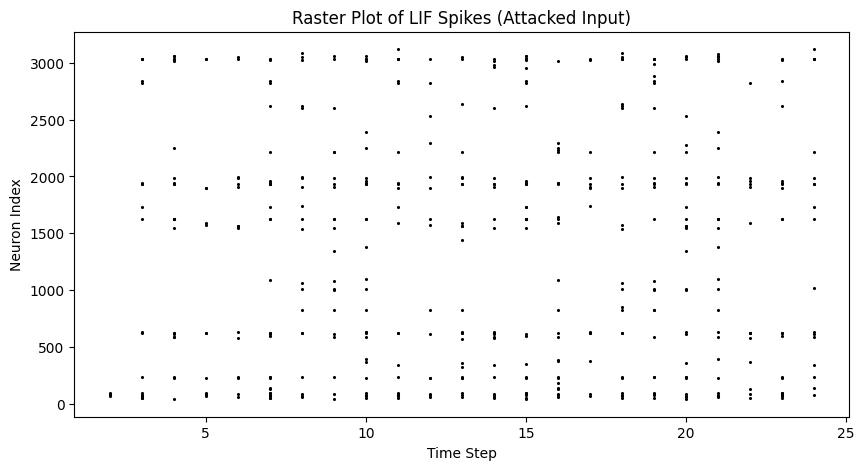

In [10]:
# Visualize spikes for one attacked example
eps = 0.2
data, target = next(iter(test_loader))
data, target = data[0:1].to(device), target[0:1].to(device)

# Attacked data
adv_data = snn_fgsm_attack(snn_model, device, data, target, eps)

# Get spikes
# We need to modify the HybridCSNN to return spikes if we want exact raster,
# but we can also use the model logic here directly for visualization.
snn_model.eval()
batch_size = adv_data.size(0)
mem = torch.zeros(batch_size, 32 * 10 * 10, device=device)
spk_rec = []
cur = snn_model.pool(torch.relu(snn_model.conv2(torch.relu(snn_model.conv1(adv_data)))))
cur = cur.view(cur.size(0), -1)

for step in range(snn_model.num_steps):
    spk, mem = snn_model.lif(cur, mem)
    spk_rec.append(spk)

spk_rec = torch.stack(spk_rec, dim=0).squeeze(1).cpu().detach() # [T, 3200]

# Plot first 50 neurons to see activity
fig = plt.figure(facecolor="w", figsize=(10, 5))
ax = fig.add_subplot(111)
splt.raster(spk_rec, ax, s=1.5, c="black")
plt.title("Raster Plot of LIF Spikes (Attacked Input)")
plt.xlabel("Time Step")
plt.ylabel("Neuron Index")
plt.show()